NAV Trend Analysis

In [1]:
!pip install plotly

In [2]:
!pip install nbformat

In [43]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')


In [4]:
import pandas as pd
import plotly_express as pio
nav=pd.read_csv("D:\\data\\02_nav_history.csv")
nav['date']=pd.to_datetime(nav['date'])

fig = pio.line(
    nav,
    x='date', 
    y='nav',
    color ='amfi_code',
    title='nav trend analysis'
    )
fig.add_vrect(
    x0='2023-01-01',
    x1='2023-12-31',
    annotation_text='Bull Run',
    fillcolor='green',
    opacity=0.2
)
fig.add_vrect(
    x0='2024-01-01',
    x1='2024-12-31',
    annotation_text='Correction',
    fillcolor='red',
    opacity=0.2
)
fig.show()


In [ ]:
# use Plotly's export (requires kaleido)
fig.write_image("chart1.png")
fig.write_image("nav_trend.png")

AttributeError: 'Figure' object has no attribute 'savefig'

The majority of mutual fund schemes showed NAV growth during 2023, indicating a broad market bull run.

AUM Growth Bar Chart

In [8]:
print(aum.columns)

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


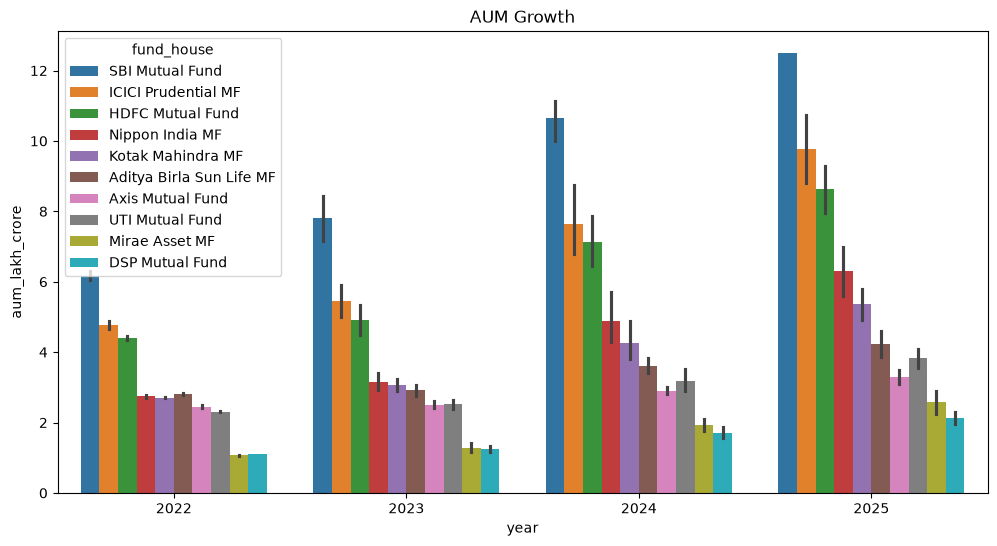

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
aum = pd.read_csv("D:\\data\\03_aum_by_fund_house.csv")
plt.figure(figsize=(12,6))
aum['date']=pd.to_datetime(aum['date'])
aum['year']=aum['date'].dt.year
sns.barplot(
    data=aum,
    x='year',
    y='aum_lakh_crore',
    hue='fund_house'
)
plt.title("AUM Growth")
plt.show()



SBI Mutual Fund maintained one of the highest AUM values across the analyzed years, demonstrating market dominance.

In [56]:
sbi = aum[aum['fund_house']=='SBI']
print(sbi)

Empty DataFrame
Columns: [date, fund_house, aum_lakh_crore, aum_crore, num_schemes, year]
Index: []


SIP Inflow Time Series

In [12]:
sip = pd.read_csv("D:\\data\\04_monthly_sip_inflows.csv")
print(sip.columns)

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


In [19]:
sip = pd.read_csv("D:\\data\\04_monthly_sip_inflows.csv")
fig = pio.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='monthly SIP Trend'
)
fig.add_annotation(
    x='2025-12',
    y=31002,
    text='All Time High rs.31,002 cr'
)
fig.show(renderer='browser')
fig.show()

SIP inflows increased consistently from 2022 to 2025 and reached their highest level in December 2025.

Category Inflow Heatmap

In [23]:
print(Category.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='str')


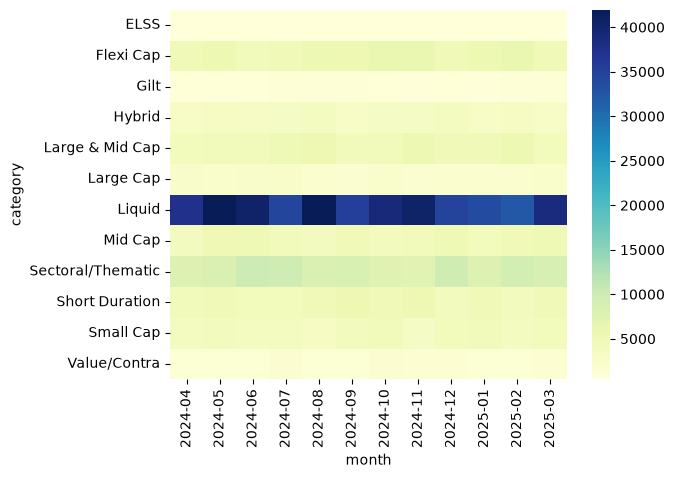

In [27]:
import pandas as pd
Category=pd.read_csv("D:\\data\\05_category_inflows.csv")
pivot=Category.pivot_table(
    values='net_inflow_crore',
    index='category',
    columns='month'
)
sns.heatmap(
    pivot,
    cmap='YlGnBu'
)
plt.show()

Purchase transactions contributed significantly higher investment amounts than other transactions types across most months.

Investors Demographics

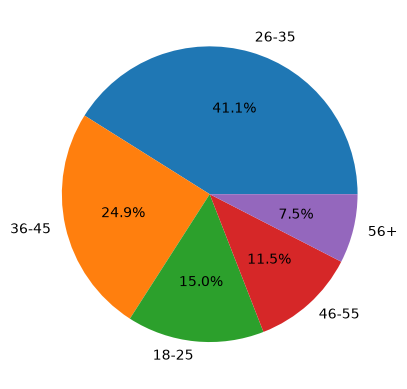

In [28]:
investor=pd.read_csv("D:\\data\\08_investor_transactions.csv")
investor['age_group'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.show()

Most investors fall within the middle-income category, suggesting mutual funds are popular among salaried professionals.

SIP Amount Box Plot

In [30]:
print(investor.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


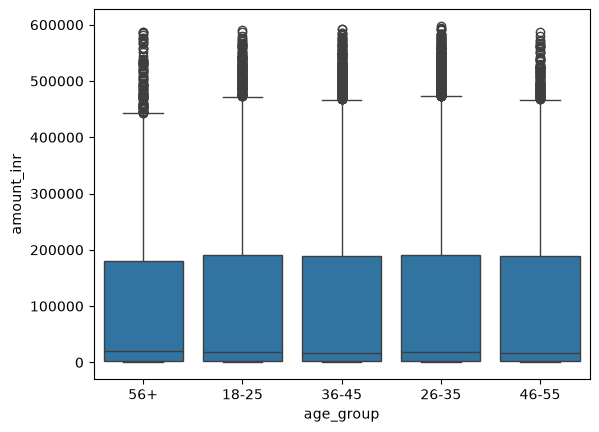

In [31]:
sns.boxplot(
    data=investor,
    x='age_group',
    y='amount_inr'
)
plt.show()

The 25-35 age group contributed the largest share of investors, showing strong participation from young investors.

Gender Split

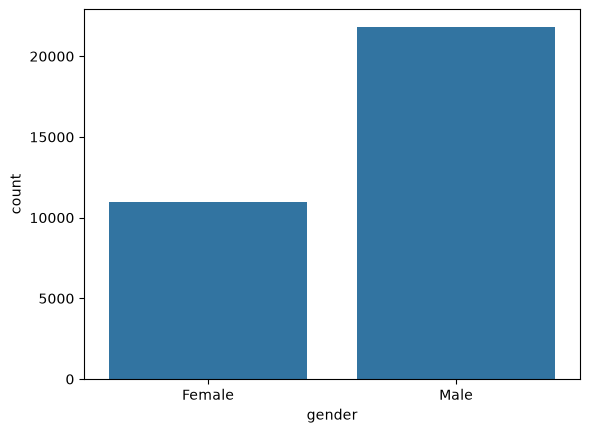

In [32]:
sns.countplot(
    data=investor,
    x='gender'
)
plt.show()

Male investors represented a larger proportion of total investors compared to female investors.

Geographic Distribution

SIP Amount by State

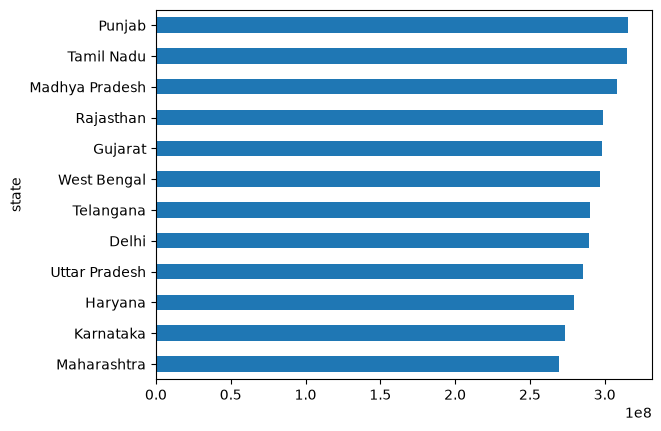

In [36]:
state_data=investor.groupby('state')['amount_inr'].sum()
state_data.sort_values().plot(
    kind='barh'
)
plt.show()

A few states contributed a major share of total investment amounts, indicating regional concentration.

T30 vs B30 pie chart

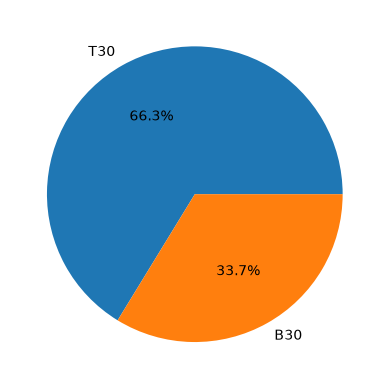

In [37]:
investor['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.show()

T30 cities account for a significant portion of mutual fund investments compared to B30 cities.

Folio Count Growth

In [39]:
print(folio.columns)

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


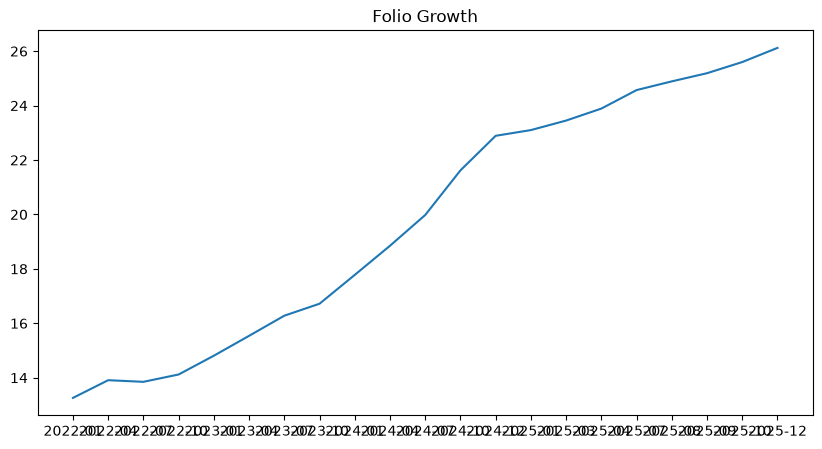

In [40]:
folio=pd.read_csv("D:\\data\\06_industry_folio_count.csv")
plt.figure(figsize=(10,5))
plt.plot(
    folio['month'],
    folio['total_folios_crore']
)
plt.title('Folio Growth')
plt.show()

Total folio count increased substantially between 2022 to 2025, indicating growing retal participation.

NAV Return Correlation Matrix

In [44]:
nav['daily_return']=(
    nav.groupby('amfi_code')['nav']
    .pct_change()
)

In [45]:
corr_data = nav.pivot_table(
    values='daily_return',
    index='date',
    columns='amfi_code'
)
corr = corr_data.corr()

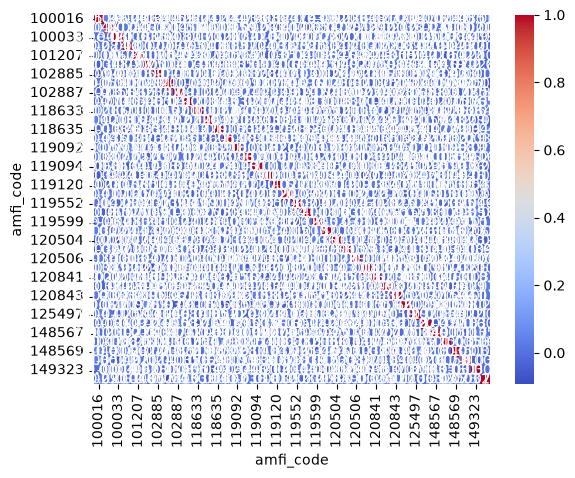

In [46]:
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.show()

Several schemes experienced slower NAV growth or temporary declines during 2024, reflecting market correction periods.

Sector Allocation Donut Chart

In [52]:
print(holdings.columns)

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [53]:
holdings=pd.read_csv("D:\\data\\09_portfolio_holdings.csv")
sector = holdings.groupby(
    'sector'
)['weight_pct'].sum()

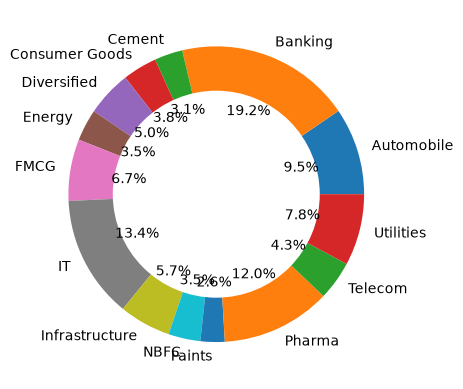

In [54]:
plt.pie(
    sector,
    labels=sector.index,
    autopct='%1.1f%%'
)
centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc='white'
)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.show()

The Financial Services and Technology sectors received the highest portfolio allocations among equity funds. 